# Comprehensive LLM Benchmark Report
This notebook loads the master benchmark results, summarizes the findings in structured tables, and provides logical charts to analyze model behavior on automotive tasks.

### 1. Load tools
We import pandas to read data and matplotlib/seaborn to create charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from IPython.display import display, Markdown

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.style.use('ggplot')
%matplotlib inline

### 2. Display Raw Benchmark Data
First, we load the raw master benchmark CSV file and display it directly in a table format to see the individual run rows.

In [2]:
# Load the master benchmark file
df = pd.read_csv("benchmark_master.csv")

# Show the first 10 rows of raw data
display(Markdown("#### Raw Benchmark Logs (First 10 rows):"))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# pd.set_option('display.max_colwidth', None)
display(df.head(15))
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')

#### Raw Benchmark Logs (First 10 rows):

,prompt_id,category,provider,run,content,latency,prompt_tokens,completion_tokens,hallucinations,hallucination_details,word_count,token_count,compression_ratio,info_density,tps,chain_of_thought_completeness,technical_correctness,logical_consistency,concept_coverage,overall_reasoning_score,mean_word,std_word,mean_token,std_token,semantic_consistency
0,1,DTC,Ollama,1,**P0300 Diagnostic Trouble Code Explained**\n\...,32.877523,561,716,0,NaN,497,716,4.371508,0.474849,21.777796,5.0,1.0,2.0,2.0,2.50,430.6,51.063098,621.6,82.843467,0.660522
1,1,DTC,Ollama,2,**P0300 Diagnostic Trouble Code Explanation**\...,25.626792,561,534,0,NaN,390,534,4.735955,0.476923,20.837567,2.0,1.0,1.0,2.0,1.50,430.6,51.063098,621.6,82.843467,0.660522
2,1,DTC,Ollama,3,**Diagnostic Trouble Code (DTC) P0300**\n\nP03...,30.159998,561,636,0,NaN,459,636,4.459119,0.516340,21.087534,5.0,1.0,1.0,1.0,2.00,430.6,51.063098,621.6,82.843467,0.660522
3,1,DTC,Ollama,4,**P0300 Diagnosis and Common Causes**\n\nThe P...,24.732203,561,518,0,NaN,355,518,4.413127,0.428169,20.944353,1.0,1.0,1.0,1.0,1.00,430.6,51.063098,621.6,82.843467,0.660522
4,1,DTC,Ollama,5,**P0300 Diagnosis and Common Causes for a 2018...,33.807102,561,704,0,NaN,452,704,4.173295,0.420354,20.824027,1.0,1.0,1.0,1.0,1.00,430.6,51.063098,621.6,82.843467,0.660522
5,1,DTC,Groq,1,### Diagnostic Trouble Code (DTC) P0300: Rando...,1.510479,571,676,0,NaN,484,676,4.744083,0.506198,447.540018,5.0,4.0,5.0,5.0,4.75,491.0,28.823601,694.6,22.473095,0.753418
6,1,DTC,Groq,2,### P0300: Random/Multiple Cylinder Misfire De...,1.453896,571,677,0,NaN,479,677,4.926145,0.557411,465.645472,5.0,5.0,5.0,5.0,5.00,491.0,28.823601,694.6,22.473095,0.753418
7,1,DTC,Groq,3,### P0300: Random/Multiple Cylinder Misfire De...,1.318981,571,731,0,NaN,546,731,4.671683,0.437729,554.215745,5.0,4.0,5.0,4.0,4.50,491.0,28.823601,694.6,22.473095,0.753418
8,1,DTC,Groq,4,### Diagnostic Trouble Code P0300: Random/Mult...,1.539059,571,711,0,NaN,485,711,4.323488,0.509278,461.970473,5.0,4.0,5.0,5.0,4.75,491.0,28.823601,694.6,22.473095,0.753418
9,1,DTC,Groq,5,### P0300: Random / Multiple Cylinder Misfire ...,1.316900,571,678,0,NaN,461,678,4.408555,0.572668,514.845465,5.0,4.0,5.0,4.0,4.50,491.0,28.823601,694.6,22.473095,0.753418


### 3. Aggregated Overall Summary Table
Next, we calculate the average and maximum performance scores grouped by each provider to give a high-level concise view.

In [3]:
df.word_count
df['word_count'] = df['word_count'].astype('int64')

In [4]:
# Calculate high level statistics per provider
summary = df.groupby('provider').agg({
    'latency': ['mean', 'max'],
    'tps': 'mean',
    'word_count': 'mean',
    'hallucinations': 'sum',
    'overall_reasoning_score': 'mean',
    'technical_correctness': 'mean',
    'semantic_consistency': 'mean'
}).reset_index()

# Rename columns for clarity
summary.columns = ['Provider', 'Avg Latency (s)', 'Max Latency (s)', 'Avg TPS', 'Avg Word Count', 'Total Mistakes', 'Avg Quality', 'Avg Correctness', 'Semantic Consistency']

display(Markdown("#### Concise Overall Performance & Quality Summary:"))
display(summary.round(2))

#### Concise Overall Performance & Quality Summary:

,Provider,Avg Latency (s),Max Latency (s),Avg TPS,Avg Word Count,Total Mistakes,Avg Quality,Avg Correctness,Semantic Consistency
0,Gemini,5.17,13.93,208.52,683.00,322,4.83,4.83,0.90
1,Groq,1.55,6.70,426.55,463.89,449,3.46,2.91,0.78
2,Ollama,26.83,63.08,21.35,404.92,595,2.20,1.72,0.74


### 4. Speed and Throughput Distribution
We use boxplots and bar charts to visually analyze inference delay and generation speed.

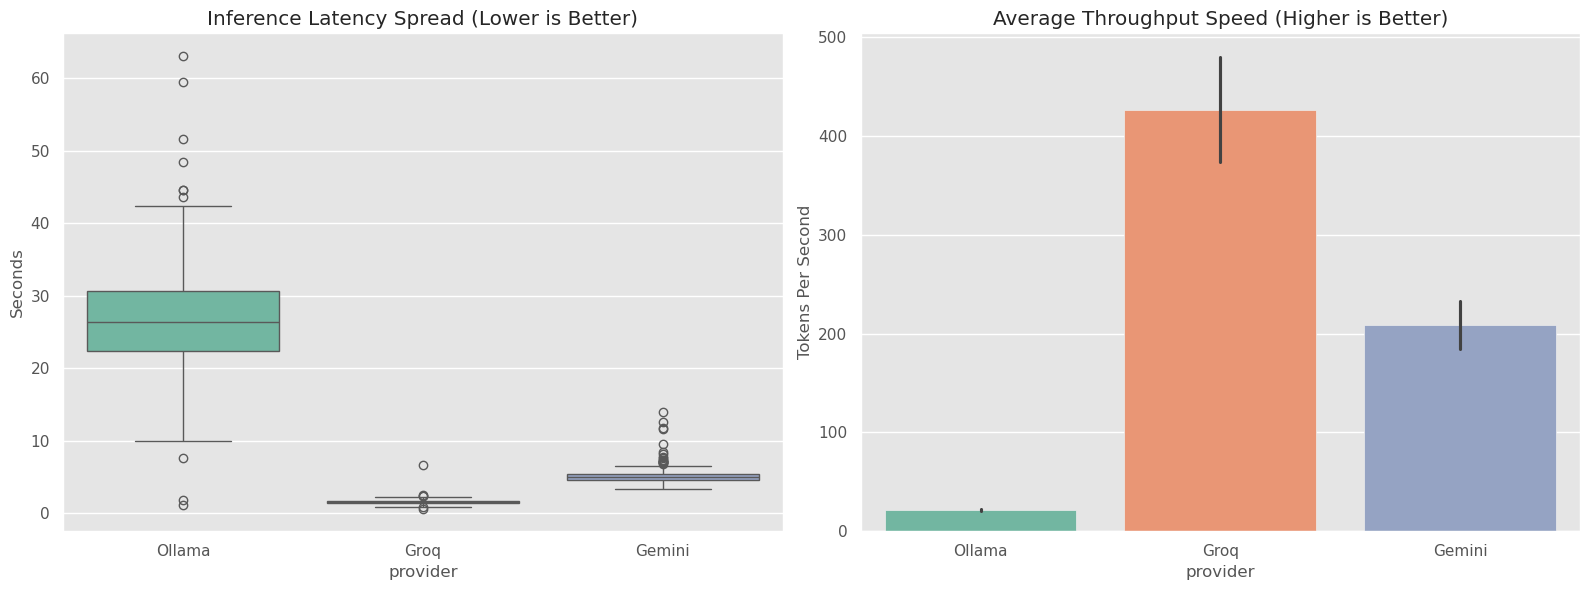

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot of Latency
sns.boxplot(x='provider', y='latency', data=df, ax=ax1, palette='Set2')
ax1.set_title('Inference Latency Spread (Lower is Better)')
ax1.set_ylabel('Seconds')

# Barplot of TPS
sns.barplot(x='provider', y='tps', data=df, ax=ax2, palette='Set2', errorbar='sd')
ax2.set_title('Average Throughput Speed (Higher is Better)')
ax2.set_ylabel('Tokens Per Second')

plt.tight_layout()
plt.show()

### 5. Quality Ratings vs. Factual Reliability
This plot compares the reasoning quality score against the number of factual mistakes to isolate high-performing reliable models.

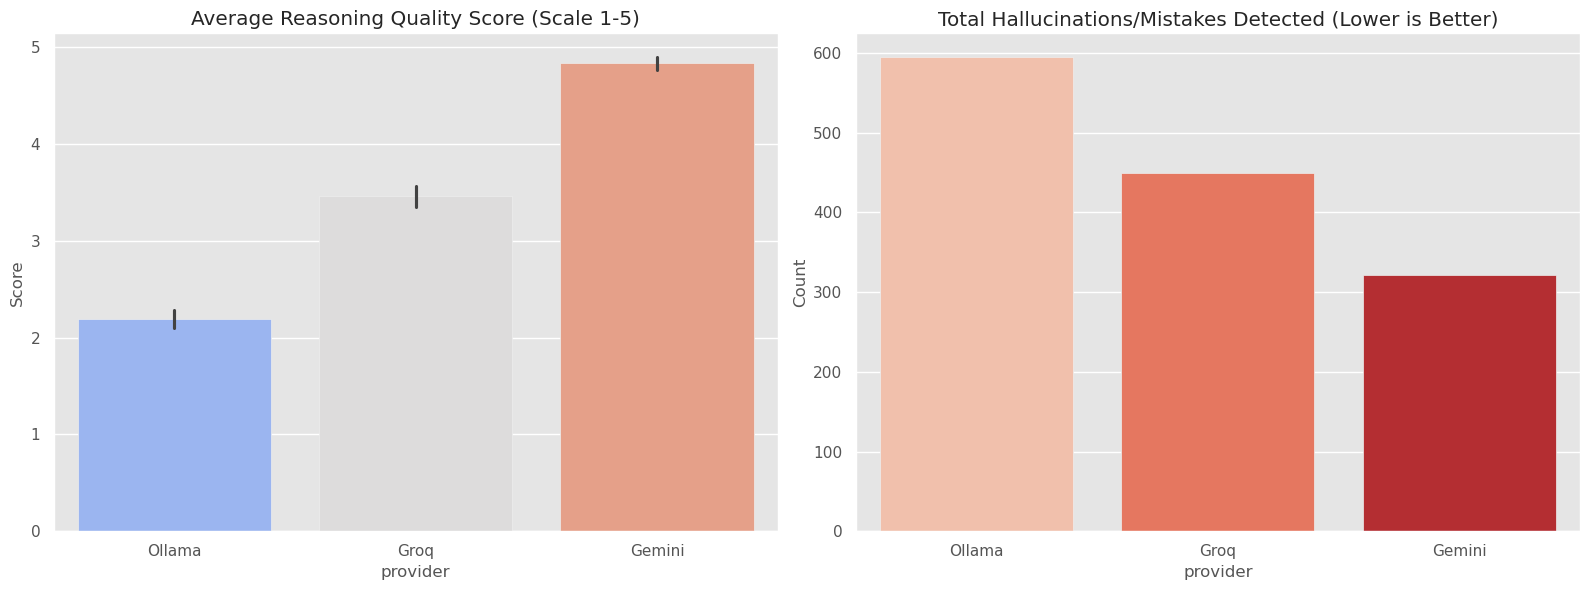

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Quality Score Bar Plot
sns.barplot(x='provider', y='overall_reasoning_score', data=df, ax=ax1, palette='coolwarm')
ax1.set_title('Average Reasoning Quality Score (Scale 1-5)')
ax1.set_ylabel('Score')

# Total Mistakes/Hallucinations Bar Plot
sns.barplot(x='provider', y='hallucinations', data=df, ax=ax2, palette='Reds', estimator=sum, errorbar=None)
ax2.set_title('Total Hallucinations/Mistakes Detected (Lower is Better)')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 6. Performance Breakdown by Domain Category
A breakdown matrix showing how each model handles specialized automotive categories.

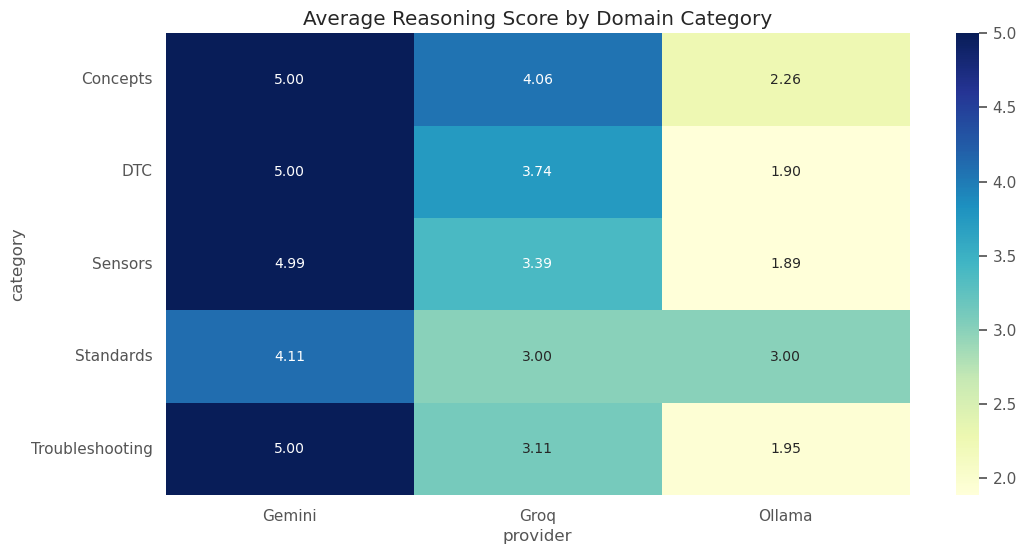

In [7]:
plt.figure(figsize=(12, 6))
pivot_df = df.pivot_table(index='category', columns='provider', values='overall_reasoning_score', aggfunc='mean')
if not pivot_df.empty:
    sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".2f", cbar=True)
    plt.title('Average Reasoning Score by Domain Category')
    plt.show()
else:
    print("Not enough categories to map heatmap.")

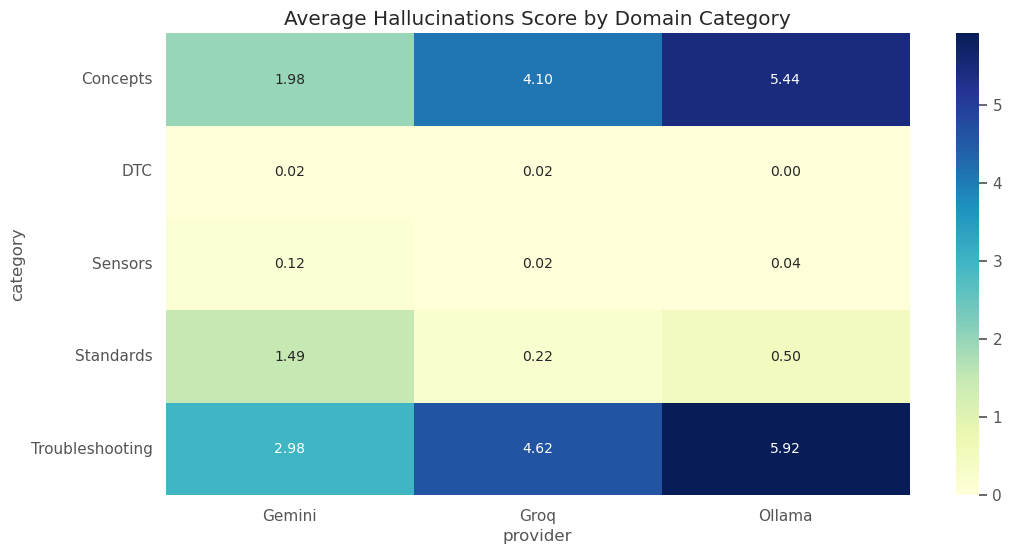

In [8]:
plt.figure(figsize=(12, 6))
pivot_df = df.pivot_table(index='category', columns='provider', values='hallucinations', aggfunc='mean')
if not pivot_df.empty:
    sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".2f", cbar=True)
    plt.title('Average Hallucinations Score by Domain Category')
    plt.show()
else:
    print("Not enough categories to map heatmap.")

### 7. Custom Framework Generation Logic
This cell contains reusable python code to load prompts dynamically from CSV, JSON, or Python Dictionary structures for generic system deployment.

In [9]:
# COMMENTED PYTHON CODE FOR CUSTOM DEMONSTRATION & REUSE
# -------------------------------------------------------------
# def generate_benchmark_from_custom_source(source_path, source_type='csv'):
#     """
#     Loads custom prompts and runs evaluation framework.
#     Supports source_type='csv', 'json', or 'dict'
#     """
#     import pandas as pd
#     import json
#     from BenchmarkFramework import run_evaluation
#     from Module1_MultiProviderInterface import GroqAdapter, GeminiAdapter, OllamaAdapter
#
#     # 1. Load Prompts
#     prompts_list = []
#     if source_type == 'csv':
#         custom_df = pd.read_csv(source_path)
#         prompts_list = custom_df.to_dict(orient='records')
#     elif source_type == 'json':
#         with open(source_path, 'r') as f:
#             prompts_list = json.load(f)
#     elif source_type == 'dict':
#         prompts_list = source_path # assumes direct list of dict passed
#
#     # 2. Configure Adapters
#     providers = [
#         GroqAdapter(api_key="YOUR_KEY"),
#         GeminiAdapter(api_key="YOUR_KEY")
#     ]
#
#     # 3. Trigger Framework
#     print(f"Loaded {len(prompts_list)} custom prompts.")
#     # results = run_evaluation(prompts_list, providers, runs_per_prompt=3)
#     # return pd.DataFrame(results)
print("Demonstration block for loading custom source lists is pre-configured and commented.")

Demonstration block for loading custom source lists is pre-configured and commented.


In [10]:
import warnings
warnings.filterwarnings('ignore')